In [1]:
import cfe
import scanpy as sc

cfe.settings.backend = "python_function"
cfe.logger.setLevel("DEBUG")

[2025年02月19日 22时14分20秒] INFO                                                                                 
                                          _____     _ _ ______    _       ______            _                      
                                         / ____|   | | |  ____|  | |     |  ____|          | |                     
                                        | |     ___| | | |__ __ _| |_ ___| |__  __  ___ __ | | ___  _ __ ___ _ __  
                                        | |    / _ \ | |  __/ _` | __/ _ \  __| \ \/ / '_ \| |/ _ \| '__/ _ \ '__| 
                                        | |___|  __/ | | | | (_| | ||  __/ |____ >  <| |_) | | (_) | | |  __/ |    
                                         \_____\___|_|_|_|  \__,_|\__\___|______/_/\_\ .__/|_|\___/|_|  \___|_|    
                                                                                     | |                           
                                                                              

数据

In [2]:
# 读取scvelo的pancreas数据
adata = sc.read_h5ad("/home/huang/PyCode/scRNA/data/Pancreas/endocrinogenesis_day15.h5ad")
fadata = cfe.data.FateAnnData.from_anndata(adata)
fadata.layers["expression"] = fadata.layers["spliced"]
fadata.layers["count"] = fadata.layers["spliced"]

basis = "umap"

# sc.pp.subsample(fadata, n_obs=500)

fadata

[2025年02月19日 22时14分21秒] DEBUG    Create a FateAnnData object from an existing AnnData object.                


AnnData object with n_obs × n_vars = 3696 × 27998
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score'
    var: 'highly_variable_genes'
    uns: 'clusters_coarse_colors', 'clusters_colors', 'day_colors', 'neighbors', 'pca', 'cfe'
    obsm: 'X_pca', 'X_umap'
    layers: 'spliced', 'unspliced', 'expression', 'count'

In [3]:
import pandas as pd

# 手动添加参考里程碑
milestone_network = pd.DataFrame(
    data=[
        ["Ductal", "Ngn3 low EP"],
        ["Ngn3 low EP", "Ngn3 high EP"],
        ["Ngn3 high EP", "Pre-endocrine"],
        ["Pre-endocrine", "Alpha"],
        ["Pre-endocrine", "Beta"],
        ["Pre-endocrine", "Delta"],
        ["Pre-endocrine", "Epsilon"],
        ],
    columns=["from", "to"]
)

fadata.add_trajectory_mannually(milestone_network)

                        DEBUG    FateAnnData add_trajectory                                                        


[2025年02月19日 22时14分31秒] DEBUG    plot_trajectory                                                             
[2025年02月19日 22时14分40秒] DEBUG    add waypoints                                                               
                        DEBUG    FateAnnData add_waypoints                                                         
[2025年02月19日 22时14分42秒] DEBUG    add waypoints shape is (212, 3696), finished!                               


AnnData object with n_obs × n_vars = 3696 × 27998
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score', 'milestone_color', 'milestone'
    var: 'highly_variable_genes'
    uns: 'clusters_coarse_colors', 'clusters_colors', 'day_colors', 'neighbors', 'pca', 'cfe', 'milestone_colors', 'milestone_color_colors'
    obsm: 'X_pca', 'X_umap', 'milestone_network_emb'
    layers: 'spliced', 'unspliced', 'expression', 'count'

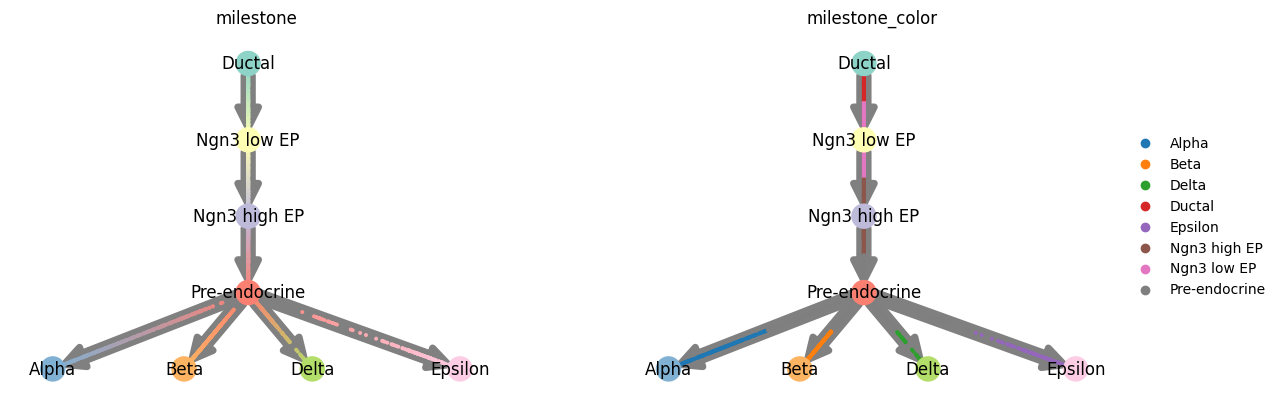

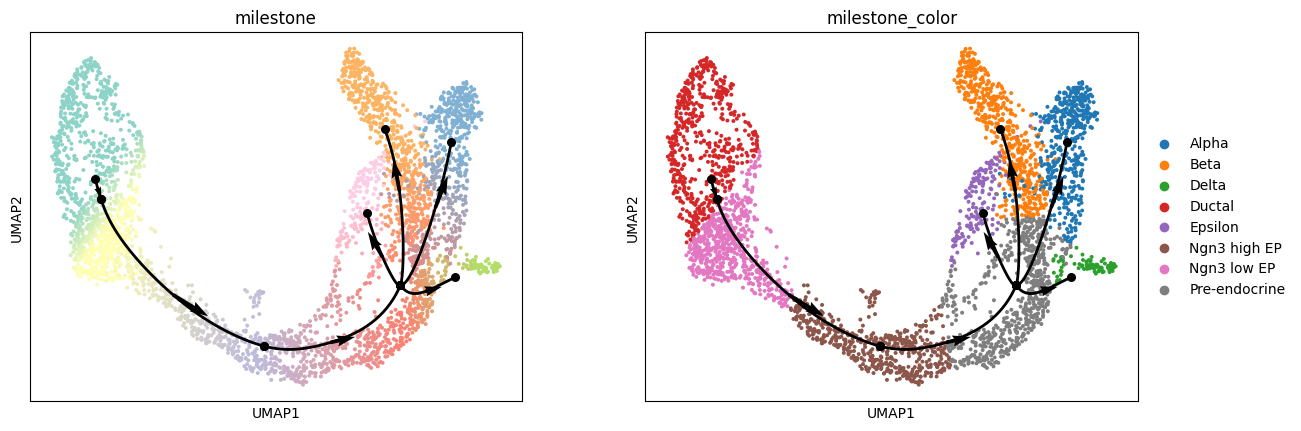

In [4]:
cluster_key = "milestone_color"
fadata.group_onto_nearest_milestones(cluster_key=cluster_key) # new cluster color

cluster_key_list = ["milestone", cluster_key]
cfe.plot.plot_graph(fadata, color=cluster_key_list)
cfe.plot.plot_trajectory(fadata, basis=basis, color=cluster_key_list)
fadata

Method and plot

[2025年02月19日 22时15分04秒] DEBUG    Docker image(dynverse/ti_slingshot:v1.0.3) loaded                           
[2025年02月19日 22时15分05秒] INFO     method_backend:                                                             
                                       <cfe.method.fate_dynverse_docker_backend.DynverseDockerBackend object at    
                                       0x73ca58347c70>                                                             
                        WARNING                                                                                    
                                                 Prior information start_id,end_id is optional, but missing from   
                                 dataset 20250219_221421__FateAnnData__153u6nkClt.                                 
                                                                                                                   
                                                 Will not give this prior to method.

<Axes: title={'center': 'milestone_color'}, xlabel='UMAP1', ylabel='UMAP2'>

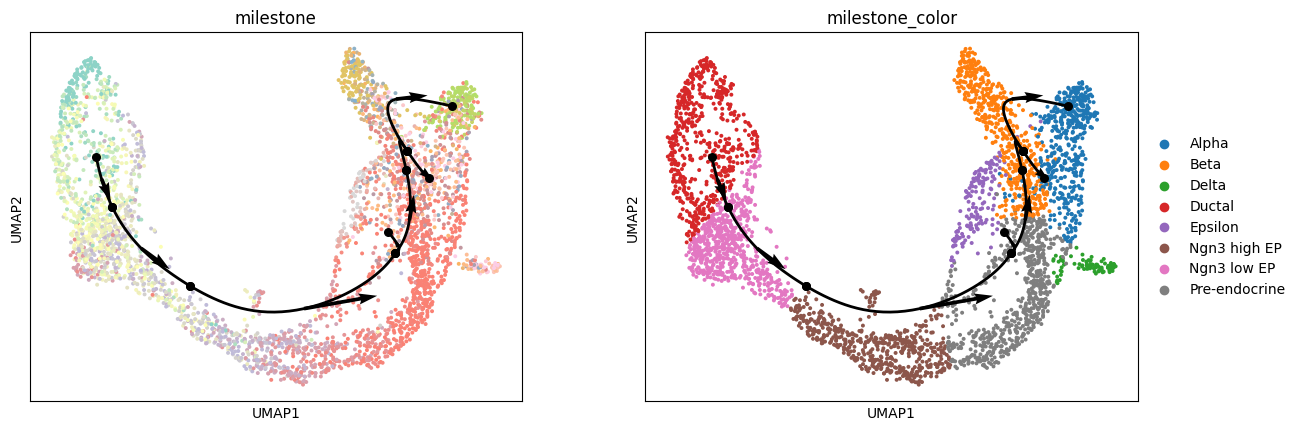

In [5]:
slingshot = cfe.method.FateMethod(method_name="slingshot", backend="dynverse_docker")

slingshot.infer_trajectory(fadata)

cfe.plot.plot_trajectory(fadata, basis=basis, color=cluster_key_list)

[2025年02月19日 22时20分07秒] DEBUG    FunctionBackend __init__                                                    
                        INFO     Loaded function: <function cf_paga at 0x73ca3c222e60> from                        
                                 /home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/method/function/cf_
                                 paga.py                                                                           
                        INFO     method_backend: <cfe.method.fate_function_backend.FunctionBackend object at       
                                 0x73ca3c2e2b30>                                                                   
Normalized count data: X, spliced, unspliced.
Logarithmized X.


/home/huang/.conda/envs/cfe/lib/python3.10/site-packages/scvelo/preprocessing/utils.py:705: DeprecationWarning: `log1p` is deprecated since scVelo v0.3.0 and will be removed in a future version. Please use `log1p` from `scanpy.pp` instead.
  log1p(adata)


[2025年02月19日 22时20分11秒] DEBUG    FateAnnData add_trajectory_branch                                           
                        DEBUG    FateAnnData add_trajectory                                                        
                        DEBUG    plot_trajectory                                                                   
                        WARNING  The number of colors(13) is greater than the number of colors in the 'Set3'       
                                 palette(12), and the 'husl' palette selection is used.                            


/home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/method/function/cf_paga.py:47: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  branches["length"] = adata.obs[[cluster_key, "dpt_pseudotime"]].groupby(cluster_key).apply(lambda x: x["dpt_pseudotime"].max() - x["dpt_pseudotime"].min() + epsilon).reset_index()[0]
/home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/plot/add_color.py:32: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping colum

[2025年02月19日 22时20分20秒] DEBUG    add waypoints                                                               
                        DEBUG    FateAnnData add_waypoints                                                         
[2025年02月19日 22时20分22秒] DEBUG    add waypoints shape is (213, 3696), finished!                               


/home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/data/fate_waypoint_wrapper.py:239: DeprecationWarning: Graph.shortest_paths() is deprecated; use Graph.distances() instead
  shortest_paths = gr.shortest_paths(source=waypoint_id_list, target=cell_id_list, weights="length", mode=mode)
/home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/data/fate_waypoint_wrapper.py:94: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda group: group.assign(
/home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/plot/plot_trajectory.py:155: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pand

<Axes: title={'center': 'milestone_color'}, xlabel='UMAP1', ylabel='UMAP2'>

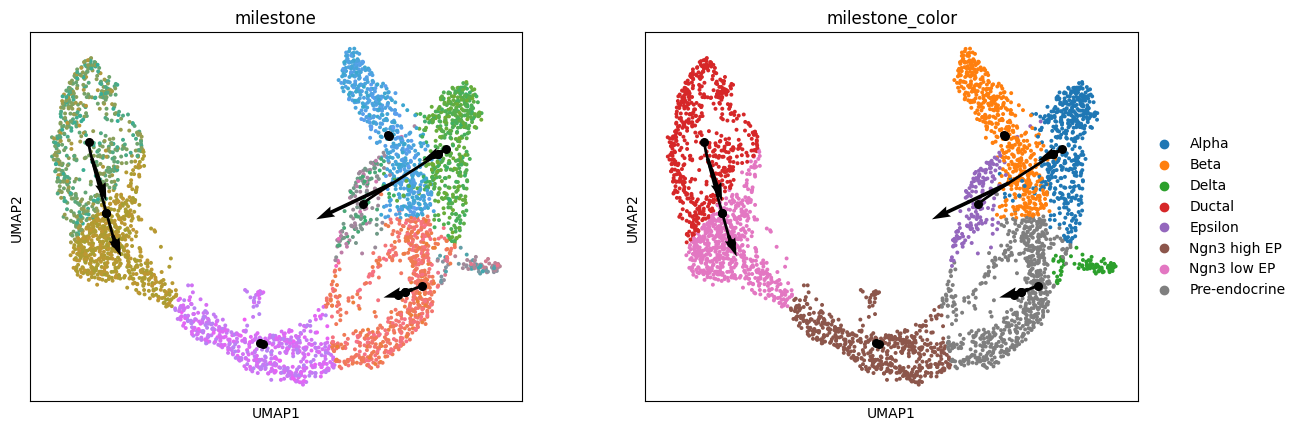

In [6]:
# TODO: PAGA need to be optimized, disconnected graph
paga_method = cfe.method.FateMethod(method_name="paga")

prior_information = {
    "start_id": fadata.obs.index[0],
    "groups_id": fadata.obs[cluster_key].tolist()
}
parameters = {"filter_features": False, "connectivity_cutoff": 0.3}
fadata.add_prior_information(**prior_information)  # add prior information to fadata
paga_method.infer_trajectory(fadata, parameters=parameters)

cfe.plot.plot_trajectory(fadata, basis=basis, color=cluster_key_list)

[2025年02月19日 22时20分34秒] DEBUG    FunctionBackend __init__                                                    
                        INFO     Loaded function: <function cf_comp1 at 0x73ca3c222ef0> from                       
                                 /home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/method/function/cf_
                                 comp1.py                                                                          
                        INFO     method_backend: <cfe.method.fate_function_backend.FunctionBackend object at       
                                 0x73cb04f26710>                                                                   
[2025年02月19日 22时20分35秒] DEBUG    FateAnnData add_trajectory                                                  
                        DEBUG    plot_trajectory                                                                   


/home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/plot/add_color.py:32: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cell_color_df = milestone_percentages.groupby("cell_id").apply(lambda mpg: mix_color(mpg))


[2025年02月19日 22时20分43秒] DEBUG    add waypoints                                                               
                        DEBUG    FateAnnData add_waypoints                                                         
[2025年02月19日 22时20分47秒] DEBUG    add waypoints shape is (201, 3696), finished!                               


/home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/data/fate_waypoint_wrapper.py:239: DeprecationWarning: Graph.shortest_paths() is deprecated; use Graph.distances() instead
  shortest_paths = gr.shortest_paths(source=waypoint_id_list, target=cell_id_list, weights="length", mode=mode)
/home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/data/fate_waypoint_wrapper.py:94: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda group: group.assign(
/home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/plot/plot_trajectory.py:155: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pand

<Axes: title={'center': 'milestone_color'}, xlabel='UMAP1', ylabel='UMAP2'>

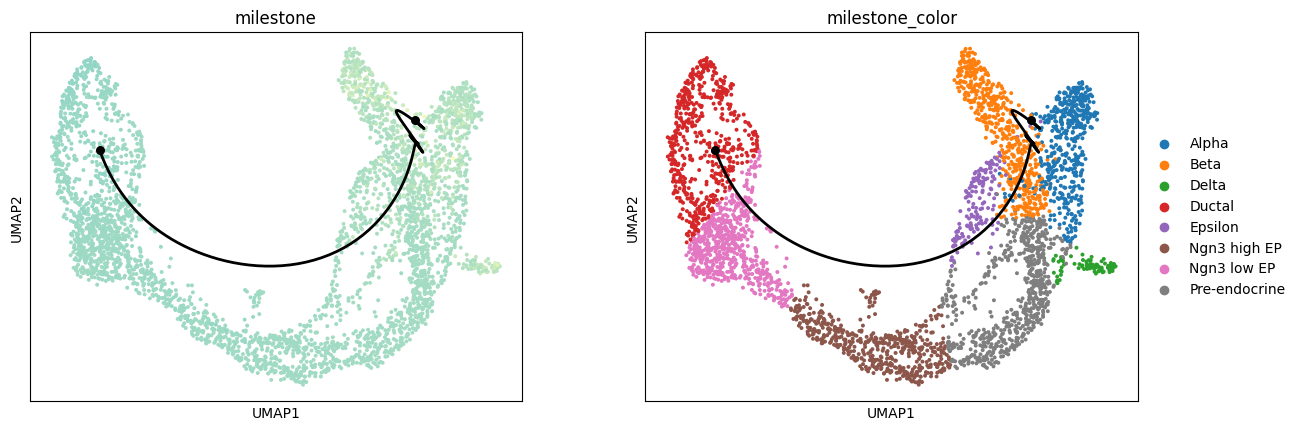

In [7]:
comp1_method = cfe.method.FateMethod(method_name="comp1")

comp1_method.infer_trajectory(fadata)

cfe.plot.plot_trajectory(fadata, basis=basis, color=cluster_key_list)

[2025年02月19日 22时20分59秒] DEBUG    FunctionBackend __init__                                                    
                        INFO     Loaded function: <function cf_mst at 0x73ca36ebeef0> from                         
                                 /home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/method/function/cf_
                                 mst.py                                                                            
                        INFO     method_backend: <cfe.method.fate_function_backend.FunctionBackend object at       
                                 0x73ca32a0fb80>                                                                   
[2025年02月19日 22时21分00秒] DEBUG    FateAnnData add_trajectory                                                  
                        DEBUG    plot_trajectory                                                                   


/home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/method/function/cf_mst.py:45: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  centers = np.array(list(adata.obs.groupby(cluster_key).apply(lambda x: X_emb[list(x.index)].mean(axis=0))))
/home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/plot/add_color.py:32: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cell_color_df = milestone_percen

[2025年02月19日 22时21分09秒] DEBUG    add waypoints                                                               
                        DEBUG    FateAnnData add_waypoints                                                         
[2025年02月19日 22时21分11秒] DEBUG    add waypoints shape is (210, 3696), finished!                               


/home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/data/fate_waypoint_wrapper.py:239: DeprecationWarning: Graph.shortest_paths() is deprecated; use Graph.distances() instead
  shortest_paths = gr.shortest_paths(source=waypoint_id_list, target=cell_id_list, weights="length", mode=mode)
/home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/data/fate_waypoint_wrapper.py:94: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda group: group.assign(
/home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/plot/plot_trajectory.py:155: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pand

<Axes: title={'center': 'milestone_color'}, xlabel='UMAP1', ylabel='UMAP2'>

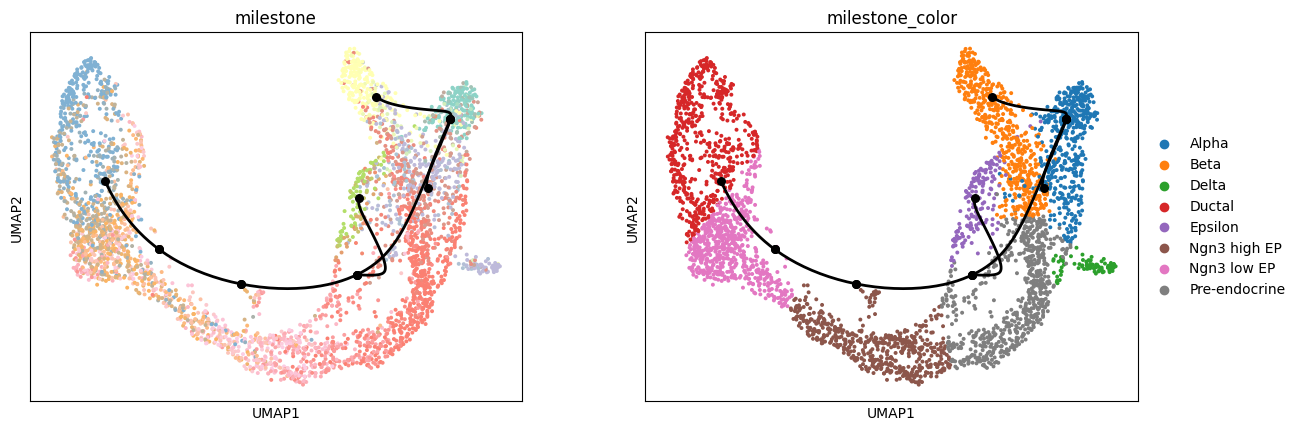

In [8]:
# TODO: MST need to be optimized
mst_method = cfe.method.FateMethod(method_name="mst", backend="python_function")

prior_information = {
    "groups_id": fadata.obs[cluster_key].tolist()
}
fadata.add_prior_information(**prior_information)  # add prior information to fadata

mst_method.infer_trajectory(fadata)

cfe.plot.plot_trajectory(fadata, basis=basis, color=cluster_key_list)

[2025年02月19日 22时21分22秒] DEBUG    FunctionBackend __init__                                                    
                        INFO     Loaded function: <function cf_scvelo at 0x73ca36ebef80> from                      
                                 /home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/method/function/cf_
                                 scvelo.py                                                                         
                        INFO     method_backend: <cfe.method.fate_function_backend.FunctionBackend object at       
                                 0x73ca32da6380>                                                                   
Filtered out 20801 genes that are detected 20 counts (shared).
Normalized count data: X, spliced, unspliced.
Extracted 2000 highly variable genes.
Logarithmized X.


/home/huang/.conda/envs/cfe/lib/python3.10/site-packages/scvelo/preprocessing/utils.py:705: DeprecationWarning: `log1p` is deprecated since scVelo v0.3.0 and will be removed in a future version. Please use `log1p` from `scanpy.pp` instead.
  log1p(adata)
/home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/method/function/cf_scvelo.py:21: DeprecationWarning: Automatic neighbor calculation is deprecated since scvelo==0.4.0 and will be removed in a future version of scVelo. Please compute neighbors first with Scanpy.
  scv.pp.moments(adata, n_pcs=30, n_neighbors=30)
/home/huang/.conda/envs/cfe/lib/python3.10/site-packages/scvelo/preprocessing/moments.py:71: DeprecationWarning: `neighbors` is deprecated since scvelo==0.4.0 and will be removed in a future version of scVelo. Please compute neighbors with Scanpy.
  neighbors(
/home/huang/.conda/envs/cfe/lib/python3.10/site-packages/scvelo/preprocessing/neighbors.py:233: DeprecationWarning: Automatic computation of PCA is deprecated

computing neighbors
    finished (0:00:00) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing moments based on connectivities
    finished (0:00:00) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)
computing velocities
    finished (0:00:00) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
computing velocity graph (using 1/24 cores)


/home/huang/.conda/envs/cfe/lib/python3.10/site-packages/scvelo/tools/optimization.py:184: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  gamma[i] = np.linalg.pinv(A.T.dot(A)).dot(A.T.dot(y[:, i]))


  0%|          | 0/3696 [00:00<?, ?cells/s]

...

    finished (0:00:03) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing terminal states
    identified 1 region of root cells and 1 region of end points .
    finished (0:00:00) --> added
    'root_cells', root cells of Markov diffusion process (adata.obs)
    'end_points', end points of Markov diffusion process (adata.obs)
running PAGA using priors: ['velocity_pseudotime']
    finished (0:00:00) --> added
    'paga/connectivities', connectivities adjacency (adata.uns)
    'paga/connectivities_tree', connectivities subtree (adata.uns)
    'paga/transitions_confidence', velocity transitions (adata.uns)
[2025年02月19日 22时21分30秒] DEBUG    FateAnnData add_trajectory                                                  
                        DEBUG    plot_trajectory                                                                   


/home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/method/function/cf_scvelo.py:34: DeprecationWarning: `get_df` is deprecated since scvelo==0.4.0 and will be removed in a future version of scVelo. Please `AnnData::get_df` or Scanpy's `scanpy.get.obs_df` or `scanpy.get.var_df`.
  df = scv.get_df(adata, "paga/transitions_confidence", precision=2).T
/home/huang/.conda/envs/cfe/lib/python3.10/site-packages/scvelo/core/_anndata.py:257: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if is_categorical_dtype(data.obs[key])
/home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/method/function/cf_scvelo.py:47: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explici

[2025年02月19日 22时21分39秒] DEBUG    add waypoints                                                               
                        DEBUG    FateAnnData add_waypoints                                                         
[2025年02月19日 22时21分41秒] DEBUG    add waypoints shape is (210, 3696), finished!                               


/home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/data/fate_waypoint_wrapper.py:239: DeprecationWarning: Graph.shortest_paths() is deprecated; use Graph.distances() instead
  shortest_paths = gr.shortest_paths(source=waypoint_id_list, target=cell_id_list, weights="length", mode=mode)
/home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/data/fate_waypoint_wrapper.py:94: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda group: group.assign(
/home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/plot/plot_trajectory.py:155: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pand

<Axes: title={'center': 'milestone_color'}, xlabel='UMAP1', ylabel='UMAP2'>

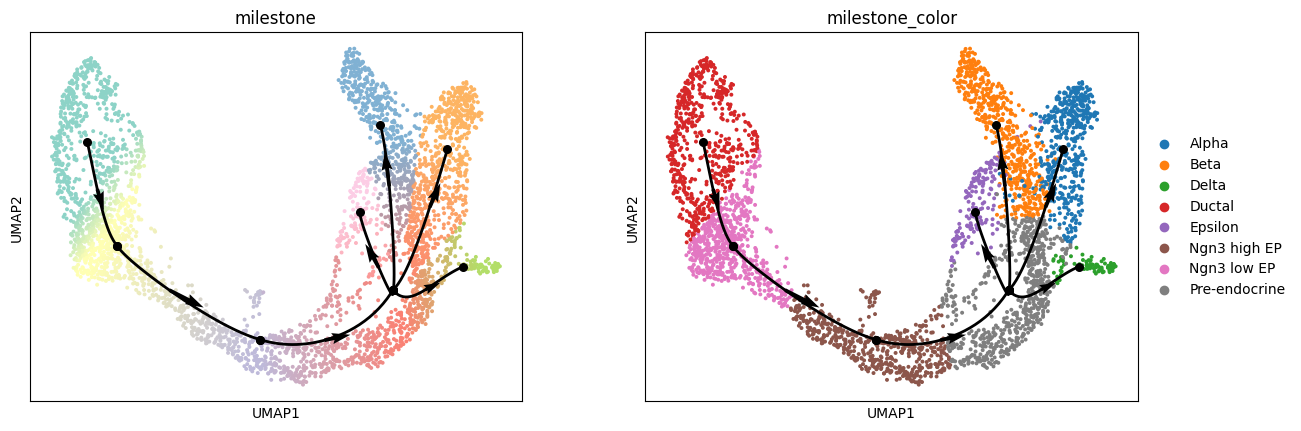

In [9]:
# scvelo

scvelo_method = cfe.method.FateMethod(method_name="scvelo", backend="python_function")

scvelo_method.infer_trajectory(fadata)

cfe.plot.plot_trajectory(fadata, basis=basis, color=cluster_key_list)

## 指标

In [10]:
parsed_model_name_list = fadata.get_all_model_name()
model_name_list = fadata.get_all_model_name(parse=False)
parsed_model_name_list, model_name_list

[2025年02月19日 22时21分53秒] WARNING  'ref' is not a valid random_time_string, don't need parse                   


(['ref',
  'slingshot-dynverse_docker',
  'paga-python_function',
  'comp1-python_function',
  'mst-python_function',
  'scvelo-python_function'],
 ['ref',
  '20250219_221505__slingshot-dynverse_docker__RXMshK6tqD',
  '20250219_222007__paga-python_function__bbYlrzxPJO',
  '20250219_222034__comp1-python_function__2UGDrO1tFg',
  '20250219_222059__mst-python_function__kAzk52NhYY',
  '20250219_222122__scvelo-python_function__khQQ4iNL9V'])

In [11]:
metrics = cfe.metric.metrics
metric_id_list = metrics[metrics["category"] == "topology"]["metric_id"].tolist()
metric_id_list

['edge_flip', 'him', 'isomorphic']

In [12]:
import pandas as pd


model_metric_dict = {}

for model_name in model_name_list:
    model_metric = cfe.metric.calculate_metrics(
        fadata,
        metrics=metric_id_list,
        now_model=model_name,
        ref_model="ref"
    )
    model_metric_dict[model_name] = model_metric

df = pd.DataFrame(model_metric_dict).T
df

,isomorphic,edge_flip,him
ref,1,0,0
20250219_221505__slingshot-dynverse_docker__RXMshK6tqD,0,0,0
20250219_222007__paga-python_function__bbYlrzxPJO,0,0,0
20250219_222034__comp1-python_function__2UGDrO1tFg,0,0,0
20250219_222059__mst-python_function__kAzk52NhYY,0,0,0
20250219_222122__scvelo-python_function__khQQ4iNL9V,1,0,0
